# Optional Project - Transformer Scaling Laws on SVGs

Vincent Hepola - vh2308


# 0. Imports


In [10]:
from IPython.display import SVG, display

import os
# Replace '/path/to/new/cache' with your desired directory
os.environ['HF_HOME'] = './.cache'
print(os.environ['HF_HOME'])

from datasets import load_dataset

import torch
import torch.nn as nn
import torch.nn.functional as F

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

from lxml import etree
import cairosvg

import numpy as np
from tqdm.auto import tqdm

import re

./.cache


# 1. Data Collecting and Preprocessing


## 1.1 Datasets


In [11]:
dataset_1 = load_dataset("starvector/svg-icons-simple")

dataset_2 = load_dataset("starvector/svg-emoji-simple")

dataset_3 = load_dataset("starvector/svg-stack-simple")

In [12]:
dataset_1

DatasetDict({
    train: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 80434
    })
    test: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 2682
    })
    val: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 6254
    })
})

In [13]:
dataset_2

DatasetDict({
    train: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 4114
    })
    test: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 646
    })
    val: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 346
    })
})

In [14]:
dataset_3

DatasetDict({
    train: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 1229633
    })
    test: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 3235
    })
    val: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 61507
    })
})

In [15]:
train_data = dataset_2["train"]

In [16]:
svgs = np.array(train_data["Svg"])

In [17]:
svgs

array(['<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M11.848124504089355 2.7946882247924805 L11.848124504089355 2.7946882247924805 C13.100765228271484 3.0658822059631348 14.25027084350586 3.787259340286255 15.525188446044922 3.9185619354248047 C17.299732208251953 4.101320743560791 17.798198699951172 2.6469357013702393 19.428375244140625 4.225686550140381 C20.382118225097656 5.149341583251953 20.817474365234375 6.728623390197754 21.017906188964844 8.370633125305176 C21.218341827392578 10.012641906738281 21.183853149414062 11.71738052368164 21.197904586791992 12.891947746276855 C21.209056854248047 13.824155807495117 21.231435775756836 15.011476516723633 20.787364959716797 15.894432067871094 C19.568708419799805 18.317516326904297 17.274372100830078 17.542585372924805 15.889688491821289 15.952123641967773 L15.889688491821289 15.952123641967773 C15.6833

### View Sample


In [18]:
sample_1 = svgs[0]
# sample_1 = np.array(dataset_2["train"]["Svg"])[0]

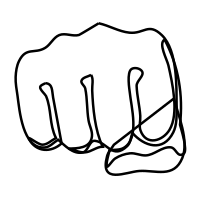

In [19]:
display(SVG(sample_1))

## 1.2 Normalizing/Cleaning

- Strip comments, metadata, and unnecessary whitespace
- Normalize coordinate precision (e.g., round to 1 decimal place) to reduce vocabulary
- Optionally canonicalize attribute ordering
- Remove SVGs that are too short (< 50 characters) or too long (above your chosen token threshold)
- Validate that all SVGs in the cleaned set parse as valid XML
- Ensure all SVGs render without errors (use lxml for XML parsing, optionally CairoSVG for render validation)


In [20]:
def clean_svg(svg_text):
    # Remove XML comments
    svg_text = re.sub(r"", "", svg_text, flags=re.DOTALL)

    # Normalize coordinates to 1 decimal place
    # \d+\.\d+ captures numbers like 0.0, 1.323, 123.4
    # Does not capture numbers like .0, 1, or 1.
    svg_text = re.sub(r"\d+\.\d+", lambda m: str(round(float(m.group(0)), 1)), svg_text)

    # Strip extra whitespace, leaving single-spaced text with no leading/trailing space
    svg_text = re.sub(r"\s+", " ", svg_text).strip()

    return svg_text

In [21]:
print(sample_1)
svg_string = clean_svg(sample_1)

print()
print(svg_string)

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M11.848124504089355 2.7946882247924805 L11.848124504089355 2.7946882247924805 C13.100765228271484 3.0658822059631348 14.25027084350586 3.787259340286255 15.525188446044922 3.9185619354248047 C17.299732208251953 4.101320743560791 17.798198699951172 2.6469357013702393 19.428375244140625 4.225686550140381 C20.382118225097656 5.149341583251953 20.817474365234375 6.728623390197754 21.017906188964844 8.370633125305176 C21.218341827392578 10.012641906738281 21.183853149414062 11.71738052368164 21.197904586791992 12.891947746276855 C21.209056854248047 13.824155807495117 21.231435775756836 15.011476516723633 20.787364959716797 15.894432067871094 C19.568708419799805 18.317516326904297 17.274372100830078 17.542585372924805 15.889688491821289 15.952123641967773 L15.889688491821289 15.952123641967773 C15.683313369750

In [22]:
TOKEN_THRESHOLD = 4096

# count = 0

# # print(len(dataset["train"]))

# for svg in tqdm(svgs):
#     svg_string  = clean_svg(svg)
#     # print(len(svg_string))
#     if len(svg_string) <= TOKEN_THRESHOLD:
#         count += 1

In [23]:
# print(count/len(dataset["train"]))

### Clean and verify all svgs in training set


In [24]:
def dict_map(d):
    cleaned_string = clean_svg(d["Svg"])
    return {"Filename": d["Filename"], "Svg": cleaned_string}


cleaned_train = train_data.map(dict_map)

Map:   0%|          | 0/4114 [00:00<?, ? examples/s]

In [25]:
print(f"cleaned_train.num_rows: {cleaned_train.num_rows}")

cleaned_train.num_rows: 4114


In [26]:
def is_valid(d):
    svg_string = d["Svg"]

    if len(svg_string) <= 50 or len(svg_string) > TOKEN_THRESHOLD:
        return False

    try:
        etree.fromstring(svg_string.encode("utf-8"))
    except etree.XMLSyntaxError:
        return False

    return True


def valid_render(d):
    svg_string = d["Svg"]

    try:
        cairosvg.svg2png(bytestring=svg_string.encode("utf-8"))
    except:
        return False

    return True


filtered_train = cleaned_train.filter(is_valid)
# filtered_train = filtered_train.filter(valid_render)

Filter:   0%|          | 0/4114 [00:00<?, ? examples/s]

In [27]:
print(f"filtered_train.num_rows: {filtered_train.num_rows}")

filtered_train.num_rows: 2954


In [28]:
filtered_train

Dataset({
    features: ['Filename', 'Svg'],
    num_rows: 2954
})

## 1.3 Tokenize

Train a BPE tokenizer on your SVG corpus using sentencepiece or the HuggingFace
tokenizers library. Vocabulary sizes in the range 1K–8K are reasonable. Document the vocabulary
size and justify your choice in the report.


In [29]:
VOCAB_SIZE = 1000
BLOCK_SIZE = 256

In [30]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

In [31]:
tokenizer = Tokenizer(models.BPE())

tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

trainer = trainers.BpeTrainer(
    special_tokens=["<|endoftext|>", "<|pad|>"], vocab_size=VOCAB_SIZE
)

In [32]:
tokenizer

Tokenizer(version="1.0", truncation=None, padding=None, added_tokens=[], normalizer=None, pre_tokenizer=Whitespace(), post_processor=None, decoder=None, model=BPE(dropout=None, unk_token=None, continuing_subword_prefix=None, end_of_word_suffix=None, fuse_unk=False, byte_fallback=False, ignore_merges=False, vocab={}, merges=[]))

In [33]:
tokenizer.train_from_iterator(filtered_train["Svg"], trainer)

In [34]:
sample_2 = filtered_train["Svg"][0]
sample_2

'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M11.8 2.8 L11.8 2.8 C13.1 3.1 14.3 3.8 15.5 3.9 C17.3 4.1 17.8 2.6 19.4 4.2 C20.4 5.1 20.8 6.7 21.0 8.4 C21.2 10.0 21.2 11.7 21.2 12.9 C21.2 13.8 21.2 15.0 20.8 15.9 C19.6 18.3 17.3 17.5 15.9 16.0 L15.9 16.0 C15.7 16.5 15.7 17.1 15.3 17.5 C13.5 19.2 12.9 17.1 11.4 16.9 C10.7 16.8 10.6 18.2 9.9 18.3 C8.7 18.6 7.7 17.4 7.0 16.8 L7.0 16.8 C6.5 17.1 6.0 17.6 5.4 17.7 C4.0 17.8 3.3 16.7 2.8 15.3 C2.4 13.9 2.2 12.3 2.1 11.5 C2.0 10.7 1.8 10.0 1.9 9.2 C1.9 8.6 2.0 7.9 2.3 7.3 C3.1 5.6 4.2 6.5 5.4 5.7 C6.1 5.3 6.4 4.5 7.1 4.2 C7.8 3.9 8.7 4.4 9.5 4.2 C9.6 4.2 11.7 2.9 11.8 2.8 L11.8 2.8"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M19.8 4.8 L19.8 4.8 C20.6 6.4 21.2 8.0 21.5 9.7 C21.8 11.4 21.8 13.2 21.6 15.0 L21.6 15.0 C21.7 15.3 22.6 18.1 22.0 18.4 C21.3 19.0 2

In [35]:
encoded_sample_2 = tokenizer.encode(sample_2)

print(encoded_sample_2)


# First 10 tokens on encoding
for id, token in zip(encoded_sample_2.ids[:10], encoded_sample_2.tokens[:10]):
    print(f"{id} -> {token}")

Encoding(num_tokens=1429, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])
17 -> <
96 -> svg
161 -> xmlns
46 -> ="
155 -> http
139 -> ://
156 -> www
4 -> .
151 -> w3
4 -> .


In [36]:
tokenizer.decode(encoded_sample_2.ids)

'< svg xmlns =" http :// www . w3 . org / 2000 / svg " viewBox =" 0 . 0 0 . 0 24 . 0 24 . 0 " height =" 200px " width =" 200px ">< path fill =" none " stroke =" black " stroke - width =". 3 " stroke - opacity =" 1 . 0 " filling =" 0 " d =" M11 . 8 2 . 8 L11 . 8 2 . 8 C13 . 1 3 . 1 14 . 3 3 . 8 15 . 5 3 . 9 C17 . 3 4 . 1 17 . 8 2 . 6 19 . 4 4 . 2 C20 . 4 5 . 1 20 . 8 6 . 7 21 . 0 8 . 4 C21 . 2 10 . 0 21 . 2 11 . 7 21 . 2 12 . 9 C21 . 2 13 . 8 21 . 2 15 . 0 20 . 8 15 . 9 C19 . 6 18 . 3 17 . 3 17 . 5 15 . 9 16 . 0 L15 . 9 16 . 0 C15 . 7 16 . 5 15 . 7 17 . 1 15 . 3 17 . 5 C13 . 5 19 . 2 12 . 9 17 . 1 11 . 4 16 . 9 C10 . 7 16 . 8 10 . 6 18 . 2 9 . 9 18 . 3 C8 . 7 18 . 6 7 . 7 17 . 4 7 . 0 16 . 8 L7 . 0 16 . 8 C6 . 5 17 . 1 6 . 0 17 . 6 5 . 4 17 . 7 C4 . 0 17 . 8 3 . 3 16 . 7 2 . 8 15 . 3 C2 . 4 13 . 9 2 . 2 12 . 3 2 . 1 11 . 5 C2 . 0 10 . 7 1 . 8 10 . 0 1 . 9 9 . 2 C1 . 9 8 . 6 2 . 0 7 . 9 2 . 3 7 . 3 C3 . 1 5 . 6 4 . 2 6 . 5 5 . 4 5 . 7 C6 . 1 5 . 3 6 . 4 4 . 5 7 . 1 4 . 2 C7 . 8 3 . 9 8 .

In [37]:
def tokenize_svg(d):

    svg_string = d["Svg"]

    ids = tokenizer.encode(svg_string).ids

    eot_token = tokenizer.token_to_id("<|endoftext|>")

    ids.append(eot_token)

    return {"Filename": d["Filename"], "Svg": d["Svg"], "input_ids": ids}

In [38]:
tokenized_train = filtered_train.map(tokenize_svg)

Map:   0%|          | 0/2954 [00:00<?, ? examples/s]

In [39]:
tokenized_train["input_ids"]

Column([[17, 96, 161, 46, 155, 139, 156, 4, 151, 4, 159, 5, 154, 5, 96, 2, 160, 46, 6, 4, 6, 6, 4, 6, 112, 4, 6, 112, 4, 6, 2, 158, 46, 117, 2, 73, 46, 117, 70, 63, 64, 46, 88, 2, 53, 46, 86, 2, 53, 3, 73, 82, 9, 2, 53, 3, 89, 46, 7, 4, 6, 2, 90, 46, 6, 2, 27, 46, 168, 4, 14, 8, 4, 14, 108, 4, 14, 8, 4, 14, 102, 4, 7, 9, 4, 7, 59, 4, 9, 9, 4, 14, 58, 4, 11, 9, 4, 15, 121, 4, 9, 10, 4, 7, 65, 4, 14, 8, 4, 12, 68, 4, 10, 10, 4, 8, 162, 4, 10, 11, 4, 7, 67, 4, 14, 12, 4, 13, 91, 4, 6, 14, 4, 10, 133, 4, 8, 55, 4, 6, 91, 4, 8, 56, 4, 13, 91, 4, 8, 54, 4, 15, 133, 4, 8, 57, 4, 14, 91, 4, 8, 58, 4, 6, 67, 4, 14, 58, 4, 15, 128, 4, 12, 66, 4, 9, 65, 4, 9, 65, 4, 11, 58, 4, 15, 60, 4, 6, 106, 4, 15, 60, 4, 6, 107, 4, 13, 60, 4, 11, 58, 4, 13, 65, 4, 7, 58, 4, 9, 65, 4, 11, 102, 4, 11, 68, 4, 8, 54, 4, 15, 65, 4, 7, 56, 4, 10, 60, 4, 15, 98, 4, 13, 60, 4, 14, 55, 4, 12, 66, 4, 8, 15, 4, 15, 66, 4, 9, 109, 4, 13, 66, 4, 12, 13, 4, 13, 65, 4, 10, 13, 4, 6, 60, 4, 14, 119, 4, 6, 60, 4, 14, 120, 4,

In [40]:
def flatten_input_ids(tokenized_dataset):
    concat_arr = []

    for arr in tokenized_dataset["input_ids"]:
        concat_arr.extend(arr)

    return concat_arr


train_input_ids = flatten_input_ids(tokenized_train)
train_input_ids = np.array(train_input_ids)

len(train_input_ids)

3621566

### Create, clean, filter, and tokenize test/val datasets


In [41]:
test_data = dataset_1["test"]
val_data = dataset_1["val"]

In [42]:
cleaned_test = test_data.map(dict_map)
filtered_test = cleaned_test.filter(is_valid)
# filtered_test = filtered_test.filter(valid_render)
tokenized_test = filtered_test.map(tokenize_svg)
test_input_ids = flatten_input_ids(tokenized_test)
test_input_ids = np.array(test_input_ids)

cleaned_val = val_data.map(dict_map)
filtered_val = cleaned_val.filter(is_valid)
# filtered_val = filtered_val.filter(valid_render)
tokenized_val = filtered_val.map(tokenize_svg)
val_input_ids = flatten_input_ids(tokenized_val)
val_input_ids = np.array(val_input_ids)

Map:   0%|          | 0/5678 [00:00<?, ? examples/s]

In [43]:
# Check the size of remaining data
all_tokens = np.concat([train_input_ids, val_input_ids, test_input_ids])
print(f"Number of tokens in data: {len(all_tokens)}")
print(
    f"Number of tokens in train: {len(train_input_ids)} -> {(len(train_input_ids)/len(all_tokens)*100):.2f}%"
)
print(
    f"Number of tokens in val: {len(val_input_ids)} -> {(len(val_input_ids)/len(all_tokens)*100):.2f}%"
)
print(
    f"Number of tokens in test: {len(test_input_ids)} -> {(len(test_input_ids)/len(all_tokens)*100):.2f}%"
)

Number of tokens in data: 10330705
Number of tokens in train: 3621566 -> 35.06%
Number of tokens in val: 4674208 -> 45.25%
Number of tokens in test: 2034931 -> 19.70%


# 2. Transformer Scaling Study

Train a family of decoder-only transformer language models of varying sizes on the SVG data. Measure the
validation loss after 1 epoch of training for each model size.


In [44]:
train_data = torch.tensor(train_input_ids)

## 2.1 Model Construction


In [45]:
class Head(nn.Module):
    """one head of self-attention"""

    def __init__(self, head_size, d_model, block_size):
        super().__init__()
        self.key = nn.Linear(d_model, head_size, bias=False)
        self.query = nn.Linear(d_model, head_size, bias=False)
        self.value = nn.Linear(d_model, head_size, bias=False)

        # 'tril' is the lower triangular matrix for masking
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape  # Batch, sequence length, embedding dimensionality (n_embd)

        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        # Compute attention scores
        wei = q @ k.transpose(-2, -1) * (C**-0.5)

        # Mask out future tokens by replacing 0s in the tril matrix with -infinity
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))

        output = F.softmax(wei, dim=-1) @ v

        return output


class MultiHeadAttention(nn.Module):
    def __init__(self, n_heads, d_model, block_size):
        super().__init__()

        head_size = d_model // n_heads

        self.heads = nn.ModuleList(
            [Head(head_size, d_model, block_size) for _ in range(n_heads)]
        )

        self.proj = nn.Linear(head_size * n_heads, d_model)

    def forward(self, x):

        # Runs input through each attention head, and glues them together side-by-side
        x = torch.concat([head(x) for head in self.heads], dim=-1)

        # Mixes the (head_size x n_heads) head outputs back to one d_model dimensional layer
        x = self.proj(x)

        return x


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=None):
        super().__init__()

        if d_ff == None:
            d_ff = 4 * d_model

        self.layer = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.layer(x)


class TransformerBlock(nn.Module):
    def __init__(self, n_heads, d_model, d_ff, block_size):
        super().__init__()

        self.MHA = MultiHeadAttention(
            n_heads=n_heads, d_model=d_model, block_size=block_size
        )
        self.ff = FeedForward(d_model=d_model, d_ff=d_ff)
        self.ln_1 = nn.LayerNorm(d_model)
        self.ln_2 = nn.LayerNorm(d_model)

    def forward(self, x):

        x = x + self.MHA(self.ln_1(x))
        x = x + self.ff(self.ln_2(x))

        return x


class CustomTransformer(nn.Module):
    """
    n_layers: The total number of identical Transformer blocks stacked on top of each other.
    n_heads: The number of parallel "attention heads" used in the Multi-Head Attention mechanism.
    d_model: The dimensionality of the input and output embeddings, also known as the "hidden size" or "embedding size".
    d_ff: The size of the hidden dimension in the position-wise feed-forward networks (MLP) within each layer.
    """

    def __init__(self, vocab_size, block_size, n_layers, n_heads, d_model, d_ff):
        super().__init__()

        self.vocab_size = vocab_size
        self.block_size = block_size
        self.n_layers = n_layers
        self.n_heads = n_heads
        self.d_model = d_model
        self.d_ff = d_ff

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.positional_embedding = nn.Embedding(block_size, d_model)

        self.blocks = nn.Sequential(
            *[
                TransformerBlock(n_heads, d_model, d_ff, block_size)
                for _ in range(n_layers)
            ]
        )

        self.ln_f = nn.LayerNorm(d_model)
        self.proj = nn.Linear(d_model, vocab_size)

    def generate(self, idx, max_new_tokens):

        # print(idx.shape)

        for _ in range(max_new_tokens):
            logits, _ = self.forward(idx[:, -self.block_size :])

            # print(logits.shape)

            logits = logits[:, -1:, :]

            # print(logits.shape)

            probs = F.softmax(logits, dim=2)
            # print(probs.shape)
            # print(probs)

            idx_next = torch.argmax(probs, dim=2)
            # print(idx_next.shape)

            idx = torch.concat((idx, idx_next), dim=1)

        return idx

    def forward(self, idx, targets=None):

        sequence_length = idx.shape[1]

        te = self.token_embedding(idx)

        pe = self.positional_embedding(torch.arange(sequence_length, device=idx.device))

        x = te + pe  # input_embedding

        x = self.blocks(x)

        x = self.ln_f(x)

        logits = self.proj(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape

            logits = logits.view(B * T, C)
            targets = targets.view(B * T)

            loss = F.cross_entropy(logits, targets)

        return logits, loss

In [46]:
model = CustomTransformer(
    vocab_size=VOCAB_SIZE,
    block_size=BLOCK_SIZE,
    n_layers=4,
    n_heads=4,
    d_model=128,
    d_ff=512,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"total_params: {total_params}")

total_params: 1081576


In [47]:
BATCH_SIZE = 64


def get_batch(split):

    if split == "train":
        data = train_input_ids
    elif split == "val":
        data = val_input_ids
    elif split == "test":
        data = test_input_ids
    else:
        Exception("Not a valid choice of split")

    ix = torch.randint(len(data) - BLOCK_SIZE, (BATCH_SIZE,))
    x = torch.stack(
        [torch.from_numpy((data[i : i + BLOCK_SIZE]).astype(np.int64)) for i in ix]
    )
    y = torch.stack(
        [
            torch.from_numpy((data[i + 1 : i + 1 + BLOCK_SIZE]).astype(np.int64))
            for i in ix
        ]
    )

    if device == "cuda":
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(
            device, non_blocking=True
        )
    else:
        x, y = x.to(device), y.to(device)

    return x, y

In [65]:
# x_test, y_test = get_batch("test")
model.eval()

# start_point = torch.randint(1, VOCAB_SIZE, size=(1, 1), device=device)
start_context = tokenizer.encode("<svg ").ids
# print(start_context)
start_point = torch.tensor([start_context], device=device)

print(start_point)
print(start_point.shape)


result = model.generate(start_point, 100)
print(result.shape)
result = result.squeeze(0).cpu().tolist()
print(result)


decoded = tokenizer.decode(result)

decoded

tensor([[17, 96]], device='mps:0')
torch.Size([1, 2])
torch.Size([1, 102])
[17, 96, 161, 46, 155, 139, 156, 4, 151, 4, 159, 5, 154, 5, 96, 2, 160, 46, 6, 4, 6, 6, 4, 6, 112, 4, 6, 112, 4, 6, 2, 158, 46, 117, 2, 73, 46, 117, 70, 63, 64, 46, 88, 2, 53, 46, 86, 2, 53, 3, 73, 82, 9, 2, 53, 3, 89, 46, 7, 4, 6, 2, 90, 46, 6, 2, 27, 46, 165, 4, 6, 7, 4, 6, 93, 4, 6, 7, 4, 6, 99, 4, 6, 7, 4, 6, 54, 4, 6, 7, 4, 6, 54, 4, 6, 7, 4, 6, 93, 4, 6, 7]


'< svg xmlns =" http :// www . w3 . org / 2000 / svg " viewBox =" 0 . 0 0 . 0 24 . 0 24 . 0 " height =" 200px " width =" 200px ">< path fill =" none " stroke =" black " stroke - width =". 3 " stroke - opacity =" 1 . 0 " filling =" 0 " d =" M12 . 0 1 . 0 L12 . 0 1 . 0 C12 . 0 1 . 0 12 . 0 1 . 0 12 . 0 1 . 0 L12 . 0 1'

## Training


In [49]:
from torch.optim import AdamW

learning_rate = 1e-3


optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

In [50]:
max_iterations = 1000
eval_interval = 100

next(model.parameters()).device


print(f"training on {next(model.parameters()).device}")

for iter in tqdm(range(max_iterations)):

    optimizer.zero_grad()

    xb, yb = get_batch("train")

    logits, loss = model(xb, yb)

    loss.backward()
    optimizer.step()

    if iter % eval_interval == 0:
        model.eval()
        with torch.inference_mode():

            val_losses = []

            for _ in range(10):
                xb_val, yb_val = get_batch("val")
                _, val_loss = model(xb_val, yb_val)

                val_losses.append(val_loss.item())

            print(f"{iter}. mean val_loss = {np.mean(val_losses):2f}")

        model.train()

training on mps:0


  0%|          | 0/1000 [00:00<?, ?it/s]

0. mean val_loss = 6.486741
100. mean val_loss = 1.779519
200. mean val_loss = 1.521642
300. mean val_loss = 1.340122
400. mean val_loss = 1.248757
500. mean val_loss = 1.050613
600. mean val_loss = 0.983309
700. mean val_loss = 0.922274
800. mean val_loss = 0.888799
900. mean val_loss = 0.878215


In [ ]:
result_trained = model.generate(start_point, 100)

result_trained = result_trained.squeeze(0).cpu().tolist()

result_trained.append[start_point]

decoded_trained = tokenizer.decode(result_trained)



decoded_trained

'< svg xmlns =" http :// www . w3 . org / 2000 / svg " viewBox =" 0 . 0 0 . 0 24 . 0 24 . 0 " height =" 200px " width =" 200px ">< path fill =" none " stroke =" black " stroke - width =". 3 " stroke - opacity =" 1 . 0 " filling =" 0 " d =" M12 . 0 1 . 2 L12 . 0 1 . 2 C14 . 4 2 . 2 14 . 4 3 . 2 14 . 4 4 . 2 C14 .'

In [56]:
display(SVG(decoded_trained))

ExpatError: not well-formed (invalid token): line 1, column 1